# Notebook 12 — Slide Tiles

Fetches satellite tiles for specific place IDs chosen for the presentation.
Saves annotated tiles (current pin + GT pin + pedestrian entry + car entry) to
`data/slides_tiles/`.

Existing tiles from `data/processed/tiles/` are also copied there.

In [2]:
import os
import shutil
from pathlib import Path

import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(".").resolve().parent
PROCESSED    = PROJECT_ROOT / "data" / "processed"
TILES_DIR    = PROCESSED / "tiles"
SLIDES_DIR   = PROJECT_ROOT / "data" / "slides_tiles"
SLIDES_DIR.mkdir(parents=True, exist_ok=True)

GOOGLE_KEY = os.environ.get("GOOGLE_MAPS_API_KEY", "")
if not GOOGLE_KEY:
    raise RuntimeError("GOOGLE_MAPS_API_KEY not found — add it to .env")

print("Slides tile dir:", SLIDES_DIR)
print("Google key loaded:", bool(GOOGLE_KEY))

Slides tile dir: /Users/shivanibelambe/Pin-To-Place/data/slides_tiles
Google key loaded: True


## Target places for presentation slides

| Slide role | Place | Why it's interesting |
|---|---|---|
| Baseline / correct pin | Five Guys | Tiny strip-mall, pin spot-on |
| Large offset example | Lowe's Garden Center | multi-tenant, 30 m offset |
| Large offset example | Walmart Clovis | Large-standalone, big box |
| Routing penalty | Tom Thumb (TX) | Parking lot barrier adds walking |
| Open space / dual entry | Chateau Burg RV Resort | Open-space tier, dual entry |
| Largest ped/car separation | PUMA | 118 m separation |
| Open space / dual entry | D'Iberville Memorial Park | Cemetery open space |
| Open space / dual entry | Plantation Place Dallas RV | RV park dual entry |
| Dual entry example | Zales Jewelers | Strip mall dual entry |

In [3]:
TARGETS = [
    {"id": "08f48c612a2e4830037070942d3acffb", "label": "Five Guys (correct pin)"},
    {"id": "08f26415008f5d0203a86030ee2215dd", "label": "Lowes Garden Center (large offset)"},
    {"id": "08f29ab99d8734420393ebd83bb96a80", "label": "Walmart Clovis (large offset)"},
    {"id": "08f26c860395a59a03ddcbf0ee7b587f", "label": "Tom Thumb TX (routing penalty)"},
    {"id": "08f489d59ab606c803517ccee128ff0f", "label": "Chateau Burg RV Resort (open space)"},
    {"id": "08f4880d8e9367210320b072a5a7d3ff", "label": "PUMA (largest ped/car separation 118m)"},
    {"id": "08f44554529961a503a33f1b232cad5b", "label": "D'Iberville Memorial Park (open space)"},
    {"id": "08f26c82d56f5b9303c8d5ac1586d26a", "label": "Plantation Place RV Park (dual entry)"},
    {"id": "08f265330356069a0319ab4542edf2a4", "label": "Zales Jewelers (dual entry)"},
]

TARGET_IDS = {t["id"] for t in TARGETS}
print(f"{len(TARGETS)} target places defined")

9 target places defined


In [4]:
# Load ground truth to get all coordinate columns
gt = pd.read_csv(PROCESSED / "ground_truth_combined.csv")
gt["id"] = gt["id"].astype(str)

coords = gt[gt["id"].isin(TARGET_IDS)].set_index("id")[
    ["name", "tier_label", "current_lat", "current_lon",
     "gt_lat", "gt_lon",
     "pedestrian_entry_lat", "pedestrian_entry_lon",
     "car_entry_lat", "car_entry_lon",
     "offset_haversine_m"]
]
print(f"Found {len(coords)} / {len(TARGETS)} target places in GT")
coords[["name", "tier_label", "offset_haversine_m"]]

Found 9 / 9 target places in GT


,name,tier_label,offset_haversine_m
id,,,
08f489d59ab606c803517ccee128ff0f,Chateau Burg RV Resort,open_space,32.981592
08f29ab99d8734420393ebd83bb96a80,Walmart Clovis - W Shaw Ave,standard_commercial,0.000000
08f26415008f5d0203a86030ee2215dd,Lowe's Garden Center,multi_tenant,0.000000
08f48c612a2e4830037070942d3acffb,Five Guys,standard_commercial,25.885219
08f26c860395a59a03ddcbf0ee7b587f,Tom Thumb,standard_commercial,25.575755
08f265330356069a0319ab4542edf2a4,Zales Jewelers,standard_commercial,21.110187
08f44554529961a503a33f1b232cad5b,D'Iberville Memorial Park,open_space,32.912222
08f4880d8e9367210320b072a5a7d3ff,PUMA,standard_commercial,0.000000
08f26c82d56f5b9303c8d5ac1586d26a,Plantation Place Dallas RV Park,open_space,32.077439


## Step 1 — Copy existing tiles from processed/tiles

In [5]:
copied = []
for place_id in TARGET_IDS:
    src = TILES_DIR / f"{place_id}.png"
    dst = SLIDES_DIR / f"{place_id}_single.png"
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)
        copied.append(place_id)
        print(f"  Copied {place_id}")

print(f"\nCopied {len(copied)} existing single-marker tiles to slides_tiles/")

  Copied 08f48c612a2e4830037070942d3acffb
  Copied 08f29ab99d8734420393ebd83bb96a80
  Copied 08f489d59ab606c803517ccee128ff0f
  Copied 08f26415008f5d0203a86030ee2215dd

Copied 4 existing single-marker tiles to slides_tiles/


## Step 2 — Fetch multi-marker tiles via Google Static Maps API

Each tile shows up to 4 markers:
- 🔴 **Red** = current Overture pin  
- 🟢 **Green** = GPT-4o ground truth (GT)  
- 🔵 **Blue** = pedestrian entry point  
- 🟡 **Yellow** = car entry point  

Center = current pin. Zoom 18 (~250 m view).

In [6]:
BASE_URL = "https://maps.googleapis.com/maps/api/staticmap"

def fetch_multi_marker_tile(
    place_id: str,
    center_lat: float, center_lon: float,
    markers: list[dict],          # [{"color": "red", "lat": .., "lon": ..}, ...]
    output_path: Path,
    zoom: int = 18,
    size: int = 640,
) -> bool:
    """Fetch a satellite tile with multiple colored markers."""
    if output_path.exists():
        print(f"  Already exists: {output_path.name}")
        return True

    params = [
        ("center", f"{center_lat},{center_lon}"),
        ("zoom", str(zoom)),
        ("size", f"{size}x{size}"),
        ("maptype", "satellite"),
        ("key", GOOGLE_KEY),
    ]
    for m in markers:
        params.append(("markers", f"color:{m['color']}|{m['lat']},{m['lon']}"))

    try:
        resp = requests.get(BASE_URL, params=params, timeout=30)
        resp.raise_for_status()
        # Google returns a 1x1 transparent PNG for bad requests — check size
        if len(resp.content) < 5000:
            print(f"  WARNING: tiny response ({len(resp.content)} bytes) for {place_id} — possible API error")
            return False
        output_path.write_bytes(resp.content)
        print(f"  Fetched: {output_path.name}")
        return True
    except Exception as e:
        print(f"  ERROR fetching {place_id}: {e}")
        return False

print("fetch_multi_marker_tile() defined")

fetch_multi_marker_tile() defined


In [7]:
import time

results = []

for target in TARGETS:
    place_id = target["id"]
    label    = target["label"]

    if place_id not in coords.index:
        print(f"SKIP {label} — not in GT")
        continue

    row = coords.loc[place_id]
    cur_lat, cur_lon = row["current_lat"], row["current_lon"]

    # Build marker list — always include current + GT
    markers = [
        {"color": "red",   "lat": cur_lat,       "lon": cur_lon},
        {"color": "green", "lat": row["gt_lat"],  "lon": row["gt_lon"]},
    ]
    if pd.notna(row.get("pedestrian_entry_lat")):
        markers.append({"color": "blue",   "lat": row["pedestrian_entry_lat"], "lon": row["pedestrian_entry_lon"]})
    if pd.notna(row.get("car_entry_lat")):
        markers.append({"color": "yellow", "lat": row["car_entry_lat"],        "lon": row["car_entry_lon"]})

    out = SLIDES_DIR / f"{place_id}_multi.png"
    print(f"\n{label}")
    ok = fetch_multi_marker_tile(place_id, cur_lat, cur_lon, markers, out)
    results.append({"id": place_id, "label": label, "success": ok})
    time.sleep(0.5)  # be polite

import pandas as pd
df_results = pd.DataFrame(results)
print("\n--- Summary ---")
print(df_results[["label", "success"]].to_string(index=False))


Five Guys (correct pin)
  Fetched: 08f48c612a2e4830037070942d3acffb_multi.png

Lowes Garden Center (large offset)
  Fetched: 08f26415008f5d0203a86030ee2215dd_multi.png

Walmart Clovis (large offset)
  Fetched: 08f29ab99d8734420393ebd83bb96a80_multi.png

Tom Thumb TX (routing penalty)
  Fetched: 08f26c860395a59a03ddcbf0ee7b587f_multi.png

Chateau Burg RV Resort (open space)
  Fetched: 08f489d59ab606c803517ccee128ff0f_multi.png

PUMA (largest ped/car separation 118m)
  Fetched: 08f4880d8e9367210320b072a5a7d3ff_multi.png

D'Iberville Memorial Park (open space)
  Fetched: 08f44554529961a503a33f1b232cad5b_multi.png

Plantation Place RV Park (dual entry)
  Fetched: 08f26c82d56f5b9303c8d5ac1586d26a_multi.png

Zales Jewelers (dual entry)
  Fetched: 08f265330356069a0319ab4542edf2a4_multi.png

--- Summary ---
                                 label  success
               Five Guys (correct pin)     True
    Lowes Garden Center (large offset)     True
         Walmart Clovis (large offset)     T

## Step 3 — Preview tiles inline


Five Guys (correct pin)


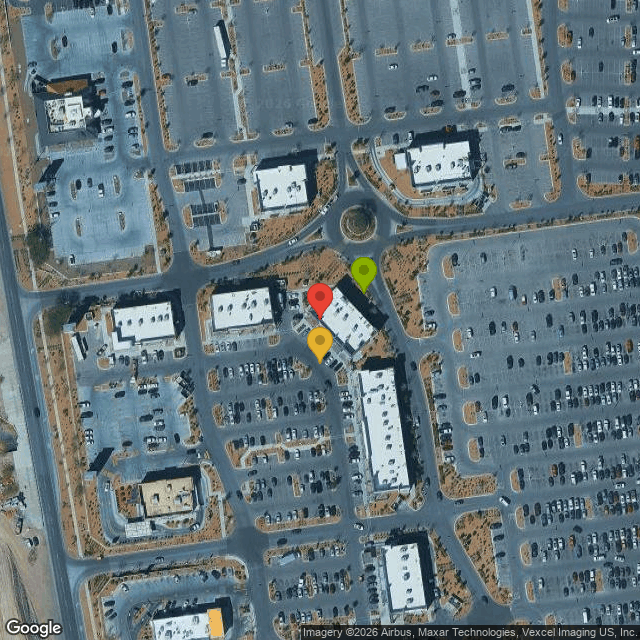


Lowes Garden Center (large offset)


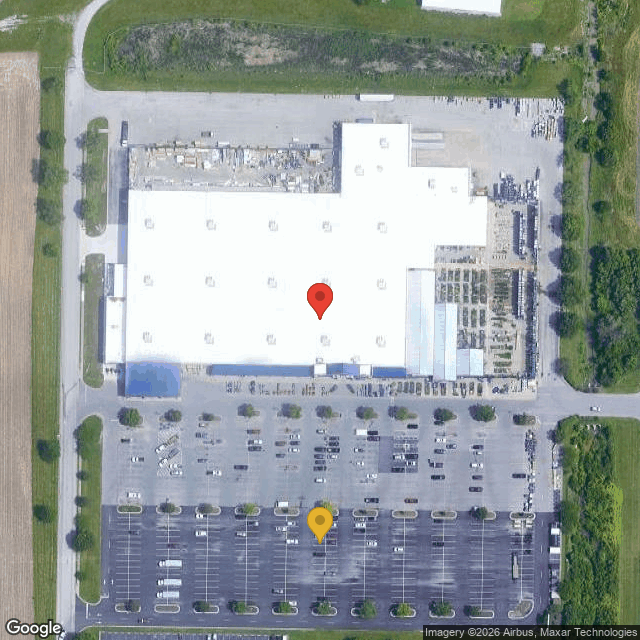


Walmart Clovis (large offset)


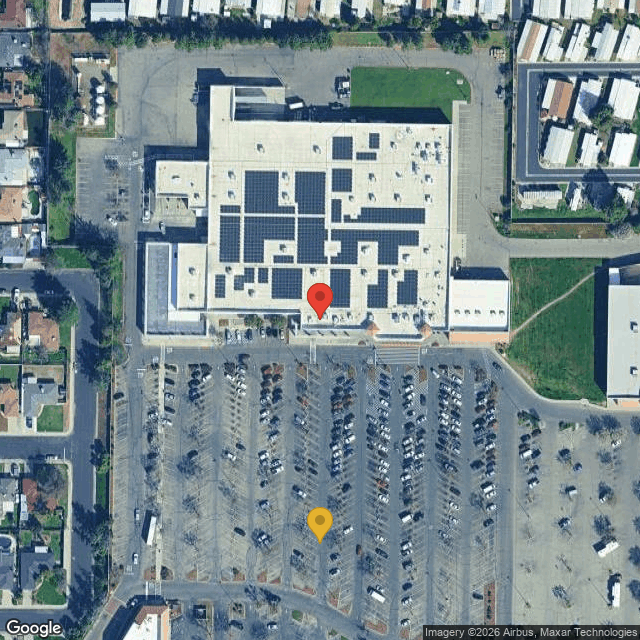


Tom Thumb TX (routing penalty)


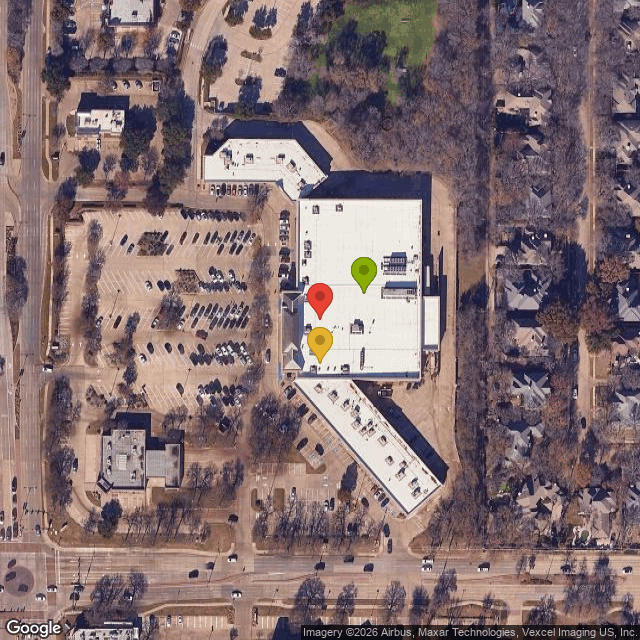


Chateau Burg RV Resort (open space)


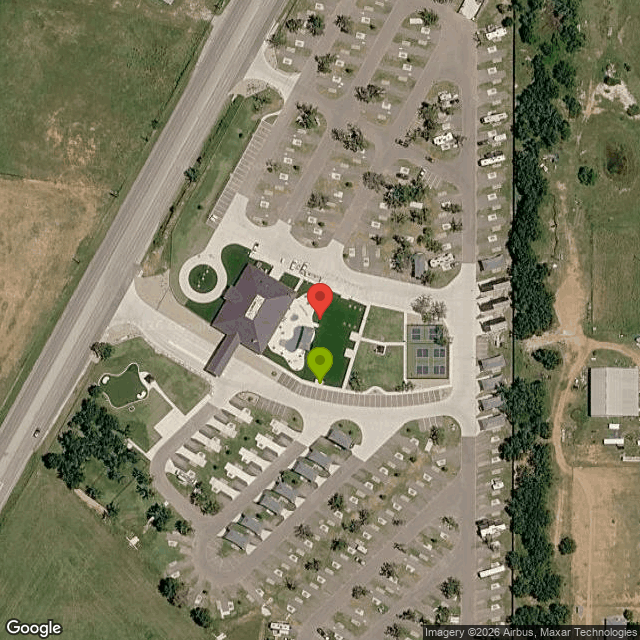


PUMA (largest ped/car separation 118m)


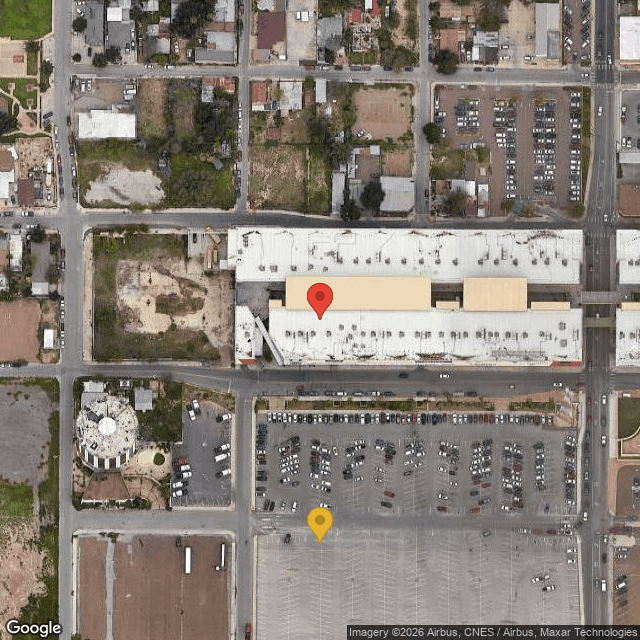


D'Iberville Memorial Park (open space)


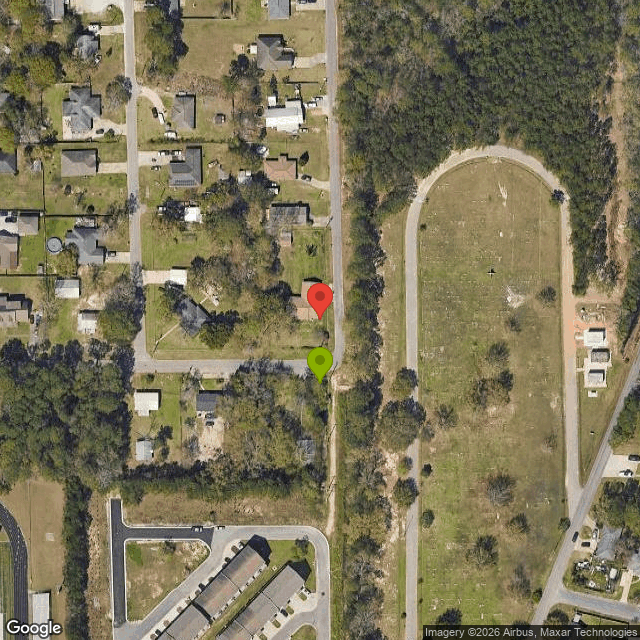


Plantation Place RV Park (dual entry)


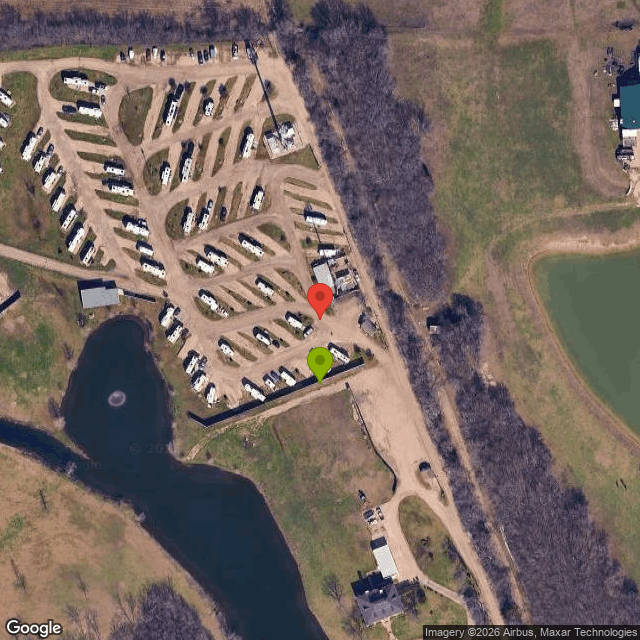


Zales Jewelers (dual entry)


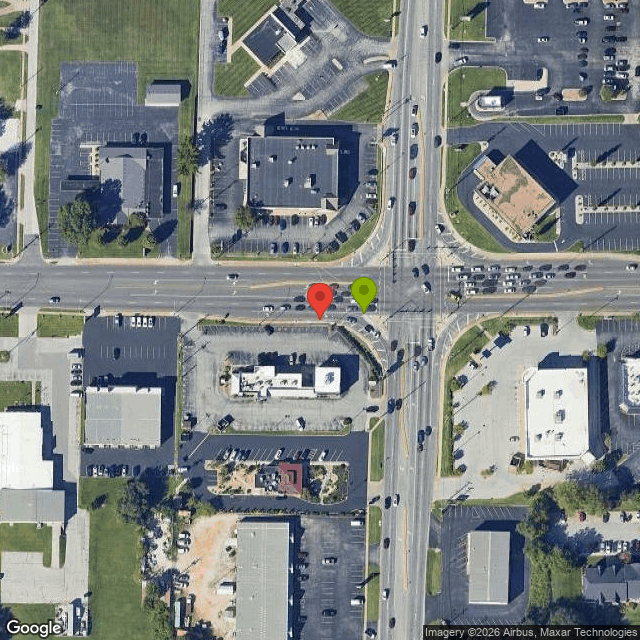

In [8]:
from IPython.display import display, Image as IPImage
from pathlib import Path

for target in TARGETS:
    place_id = target["id"]
    label    = target["label"]
    multi    = SLIDES_DIR / f"{place_id}_multi.png"
    single   = SLIDES_DIR / f"{place_id}_single.png"

    tile = multi if multi.exists() else single
    if tile.exists():
        print(f"\n{label}")
        display(IPImage(filename=str(tile), width=400))
    else:
        print(f"\n{label} — NO TILE FOUND")

## Step 4 — Marker legend reminder

When using tiles in slides, add a legend:

| Marker | Meaning |
|--------|--------|
| 🔴 Red | Current Overture pin |
| 🟢 Green | GPT-4o ground truth |
| 🔵 Blue | Pedestrian entry point |
| 🟡 Yellow | Car / drive entry point |

In [9]:
# List all tiles saved
print("Files in data/slides_tiles/:")
for f in sorted(SLIDES_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

Files in data/slides_tiles/:
  08f26415008f5d0203a86030ee2215dd_multi.png  (223 KB)
  08f26415008f5d0203a86030ee2215dd_single.png  (127 KB)
  08f265330356069a0319ab4542edf2a4_multi.png  (286 KB)
  08f26c82d56f5b9303c8d5ac1586d26a_multi.png  (271 KB)
  08f26c860395a59a03ddcbf0ee7b587f_multi.png  (311 KB)
  08f29ab99d8734420393ebd83bb96a80_multi.png  (279 KB)
  08f29ab99d8734420393ebd83bb96a80_single.png  (175 KB)
  08f44554529961a503a33f1b232cad5b_multi.png  (320 KB)
  08f4880d8e9367210320b072a5a7d3ff_multi.png  (275 KB)
  08f489d59ab606c803517ccee128ff0f_multi.png  (270 KB)
  08f489d59ab606c803517ccee128ff0f_single.png  (179 KB)
  08f48c612a2e4830037070942d3acffb_multi.png  (296 KB)
  08f48c612a2e4830037070942d3acffb_single.png  (191 KB)
